# Intro

 Transfer Learning means we take all parameters from some already trained model and we apply it to our data. However, we can't simply apply raw pretrained model on new data. That's why we need fine-tuning. We have 2 ways of transfer learning:

 1. Freezing all layers but out layer, which being finetuned based on our actual data
 2. No Freezing, we fine tune whole model

Use transfer learning when:

1. problem is similar to a problem that someone else has solved and published their model
2. the model was trained on a lot more data than what you have
3. the model is deep; shallow models are less likely to transfer well unless the target data are very similar


# MNIST (Digits) Transfor to FMNIST (Clothes)

## Imports

In [42]:
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torchsummary import summary

import copy

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

## MNIST Data

In [43]:
data = np.loadtxt(open('/content/sample_data/mnist_train_small.csv', 'rb'), delimiter = ',')

labels = data[:, 0]
data = data[:, 1:]

data = data / np.max(data)

labelsT = torch.tensor(labels).long()
dataT = torch.tensor(data).float()

# reshape the data
dataT = dataT.view(dataT.shape[0],1,28,28)
dataT.shape, labelsT.shape

(torch.Size([20000, 1, 28, 28]), torch.Size([20000]))

In [44]:
X_train, X_test, y_train, y_test = train_test_split(dataT, labelsT, test_size = .8)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([4000, 1, 28, 28]),
 torch.Size([16000, 1, 28, 28]),
 torch.Size([4000]),
 torch.Size([16000]))

In [45]:
train_dataset, test_dataset = TensorDataset(X_train, y_train), TensorDataset(X_test, y_test)

batch_size = 32
mnist_train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True, drop_last = True)
mnist_test_dataloader = DataLoader(test_dataset, batch_size = X_test.shape[0], shuffle = False)

## Model

In [46]:
def CreateModel(verbose):

  class CreateNet(nn.Module):
    def __init__(self, verbose):
      super().__init__()

      kernel_size = 5
      stride = 1
      padding = 1
      dim0 = 28 # dimension of input image - since we have square image (H = W) we can just leave dim0


      ### CONVOLUTION BLOCK ###
      self.conv1 = nn.Conv2d(in_channels = 1,
                            out_channels = 10,
                            kernel_size = kernel_size,
                            stride = stride,
                            padding = padding)

      # formula for dimension
      dim1 = torch.floor( torch.tensor((dim0 + 2 * padding - kernel_size)/stride )) + 1
      # maxpool change
      dim1 = dim1 // 2

      self.conv2 = nn.Conv2d(in_channels = 10,
                            out_channels = 20,
                            kernel_size = kernel_size,
                            stride = stride,
                            padding = padding)

      # formula for dimension
      dim2 = torch.floor( torch.tensor((dim1 + 2 * padding - kernel_size) / stride )) + 1
      # maxpool change
      dim2 = dim2 // 2

      ### FCN ###
      # we need to count input_shape (in_channels, dim, dim) = in_channels * dim * dim
      fcn_dim = 20 * int(dim2 * dim2)

      self.fc1 = nn.Linear(fcn_dim, 50)
      self.out = nn.Linear(50, 10)

      self.verbose = verbose

    def forward(self, x):
      # convolution -> maxpool -> relu
      x = F.relu(F.max_pool2d(self.conv1(x), 2))
      if self.verbose: print(f'Conv1/Pool1 shape: {x.shape}')

      x = F.relu(F.max_pool2d(self.conv2(x), 2))
      if self.verbose: print(f'Conv2/Pool2 shape: {x.shape}')

      # reshape data for fc layer
      n_units = x.numel() / x.shape[0]
      x = x.view(-1, int(n_units))
      if self.verbose: print(f'Vectorize: {x.shape}')

      # linear
      x = F.relu(self.fc1(x))
      if self.verbose: print(f'FC1 shape: {x.shape}')

      y = self.out(x)
      if self.verbose: print(f'Out shape: {y.shape}')

      return y

  net = CreateNet(verbose)
  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(net.parameters(), lr = 0.001)

  return net, loss_fn, optimizer

In [47]:
net, loss_fn, optimizer = CreateModel(True)

X, y = next(iter(mnist_train_dataloader))
y_hat = net(X)

# check sizes of model outputs and target variable
print(' ')
print(y_hat.shape)
print(y.shape)

# now let's compute the loss
loss = loss_fn(y_hat, y)
print(' ')
print('Loss:')
print(loss)

Conv1/Pool1 shape: torch.Size([32, 10, 13, 13])
Conv2/Pool2 shape: torch.Size([32, 20, 5, 5])
Vectorize: torch.Size([32, 500])
FC1 shape: torch.Size([32, 50])
Out shape: torch.Size([32, 10])
 
torch.Size([32, 10])
torch.Size([32])
 
Loss:
tensor(2.2945, grad_fn=<NllLossBackward0>)


/tmp/ipython-input-407162436.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dim2 = torch.floor( torch.tensor((dim1 + 2 * padding - kernel_size) / stride )) + 1


In [48]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

In [49]:
summary(net.to(device), (1,28,28))

Conv1/Pool1 shape: torch.Size([2, 10, 13, 13])
Conv2/Pool2 shape: torch.Size([2, 20, 5, 5])
Vectorize: torch.Size([2, 500])
FC1 shape: torch.Size([2, 50])
Out shape: torch.Size([2, 10])
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 10, 26, 26]             260
            Conv2d-2           [-1, 20, 11, 11]           5,020
            Linear-3                   [-1, 50]          25,050
            Linear-4                   [-1, 10]             510
Total params: 30,840
Trainable params: 30,840
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.07
Params size (MB): 0.12
Estimated Total Size (MB): 0.19
----------------------------------------------------------------


## Train Model

In [50]:
# a function that trains the model
def ModelTrain(train_dataloader, test_dataloader, net, verbose, epochs):

  # initialize losses
  losses = torch.zeros(epochs)
  train_acc = []
  test_acc = []

  # loop over epochs
  for epoch in range(epochs):
    net.train()
    batch_acc = []
    batch_loss = []

    for X,y in train_dataloader:

      # forward pass and loss
      y_hat = net(X)
      loss = loss_fn(y_hat, y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss from this batch
      batch_loss.append(loss.item())

      # compute accuracy
      matches = (torch.argmax(y_hat, axis = 1) == y).float()
      accuracy = 100 * torch.mean(matches)
      batch_acc.append(accuracy)
    # end of batch loop...

    # now that we've trained through the batches, get their average training accuracy
    train_acc.append(np.mean(batch_acc))

    # losses
    losses[epoch] = np.mean(batch_loss)

    # test accuracy
    net.eval()
    X, y = next(iter(test_dataloader))
    with torch.no_grad():
      y_hat = net(X)

    test_acc.append(
        100 * torch.mean(
            (torch.argmax(y_hat, axis = 1) == y).float()
        )
    )

    print(f'Epoch: {epoch} | Train Acc: {train_acc[-1]:.2f} | Test Acc: {test_acc[-1]:.2f}')
  # end epochs

  # output
  return train_acc, test_acc, losses, net

In [51]:
mnist_net, loss_fn, optimizer = CreateModel(verbose = False)

/tmp/ipython-input-407162436.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dim2 = torch.floor( torch.tensor((dim1 + 2 * padding - kernel_size) / stride )) + 1


In [52]:
mnist_train_acc, mnist_test_acc, mnist_losses, mnist_net = ModelTrain(mnist_train_dataloader,
                                                                      mnist_test_dataloader,
                                                                      mnist_net,
                                                                      verbose = False,
                                                                      epochs = 10)

Epoch: 0 | Train Acc: 65.62 | Test Acc: 88.28
Epoch: 1 | Train Acc: 89.93 | Test Acc: 90.14
Epoch: 2 | Train Acc: 92.53 | Test Acc: 94.17
Epoch: 3 | Train Acc: 94.55 | Test Acc: 93.73
Epoch: 4 | Train Acc: 95.85 | Test Acc: 95.56
Epoch: 5 | Train Acc: 96.40 | Test Acc: 95.61
Epoch: 6 | Train Acc: 96.62 | Test Acc: 94.98
Epoch: 7 | Train Acc: 97.45 | Test Acc: 95.79
Epoch: 8 | Train Acc: 97.85 | Test Acc: 95.81
Epoch: 9 | Train Acc: 98.20 | Test Acc: 96.08


## Plot

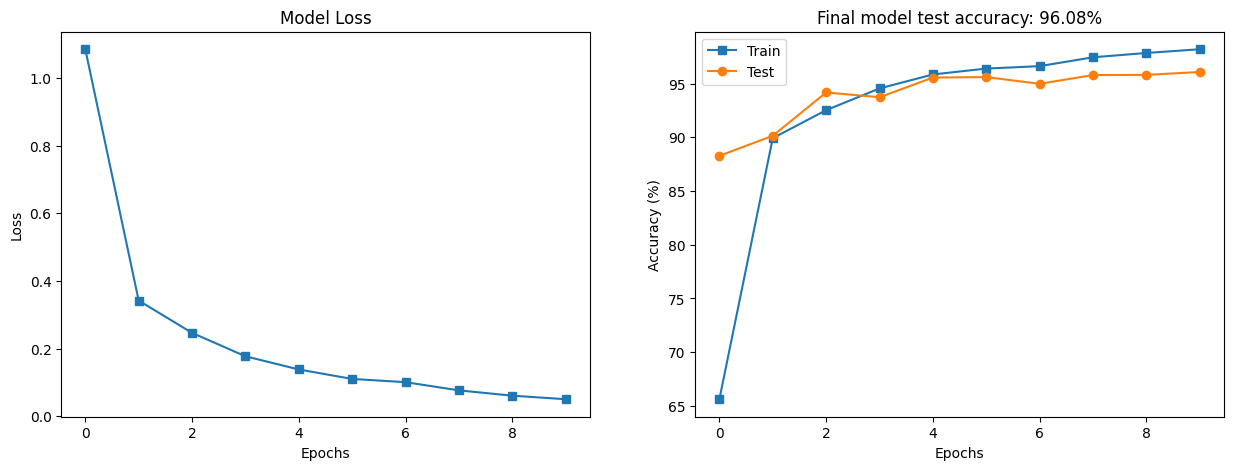

In [53]:
fig, ax = plt.subplots(1,2,figsize=(15,5))

ax[0].plot(mnist_losses, 's-')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Model Loss')

ax[1].plot(mnist_train_acc, 's-', label = 'Train')
ax[1].plot(mnist_test_acc, 'o-', label = 'Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title(f'Final model test accuracy: {mnist_test_acc[-1]:.2f}%')
ax[1].legend()

plt.show()

## FMNIST Data

In [54]:
from torchvision.datasets import FashionMNIST
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_ds = FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_ds = FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [55]:
batch_size = 32
fmnist_train_dataloader = DataLoader(train_ds, batch_size = batch_size, shuffle = True)
fmnist_test_dataloader = DataLoader(test_ds, batch_size = len(test_ds), shuffle = False)

## Test trained MNIST_net on FMNIST Data

In [56]:
X, y = next(iter(fmnist_test_dataloader))

y_hat = mnist_net(X)
loss = loss_fn(y_hat, y)
matches = (torch.argmax(y_hat, axis = 1) == y).float()
accuracy = 100 * torch.mean(matches)
print(f'Raw trained MNIST_net on FMNIST data return {accuracy:.2f}% of Acc')

Raw trained MNIST_net on FMNIST data return 9.26% of Acc


## Transfer weights from MNIST_net to FMNIST

In [57]:
fmnist_net, loss_fn, optimizer = CreateModel(verbose = False)

/tmp/ipython-input-407162436.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dim2 = torch.floor( torch.tensor((dim1 + 2 * padding - kernel_size) / stride )) + 1


In [58]:
for source, target in zip(mnist_net.named_parameters(), fmnist_net.named_parameters()):
  target[1].data = copy.deepcopy(source[1].data)

## Test Transfered FMNIST without Fine Tuning

In [59]:
X, y = next(iter(fmnist_test_dataloader))

y_hat = fmnist_net(X)
loss = loss_fn(y_hat, y)
matches = (torch.argmax(y_hat, axis = 1) == y).float()
accuracy = 100 * torch.mean(matches)
print(f'Raw trained MNIST_net on FMNIST return {accuracy:4f}% of acc')

Raw trained MNIST_net on FMNIST return 9.260000% of acc


## Fine Tune FMNIST

In [60]:
fmnist_train_acc, fmnist_test_acc, fmnist_losses, fmnist_net = ModelTrain(fmnist_train_dataloader,
                                                                          fmnist_test_dataloader,
                                                                          fmnist_net,
                                                                          verbose = False,
                                                                          epochs = 1)

Epoch: 0 | Train Acc: 82.15 | Test Acc: 85.66


## Test Fine Tuned Model

In [64]:
X, y = next(iter(fmnist_test_dataloader))

y_hat = fmnist_net(X)
loss = loss_fn(y_hat, y)
matches = (torch.argmax(y_hat, axis = 1) == y).float()
accuracy = 100 * torch.mean(matches)
print(f'Fine-Tuned (1 epoch) pre-trained MNIST_net on FMNIST return {accuracy:.2f}% of Acc')

Fine-Tuned (1 epoch) pre-trained MNIST_net on FMNIST return 85.66% of Acc


Raw FMNIST

Let's now see how the FMNIST will perform after 1 epoch when training from scratch.

In [65]:
raw_fmnist_net, loss_fn, optimizer = CreateModel(verbose = False)

/tmp/ipython-input-407162436.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dim2 = torch.floor( torch.tensor((dim1 + 2 * padding - kernel_size) / stride )) + 1


In [66]:
raw_fmnist_train_acc, raw_fmnist_test_acc, raw_fmnist_losses, raw_fmnist_net = ModelTrain(fmnist_train_dataloader,
                                                                                          fmnist_test_dataloader,
                                                                                          raw_fmnist_net,
                                                                                          verbose = False,
                                                                                          epochs = 1)

Epoch: 0 | Train Acc: 80.52 | Test Acc: 85.68


In [69]:
X, y = next(iter(fmnist_test_dataloader))

y_hat = raw_fmnist_net(X)
loss = loss_fn(y_hat, y)
matches = (torch.argmax(y_hat, axis = 1) == y).float()
accuracy = 100 * torch.mean(matches)
print(f'Raw FMNIST after 1 epoch train return {accuracy:.2f}% of Acc')

Raw FMNIST after 1 epoch train return 85.68% of Acc


Well, we have better outcome after 1 epoch on FMNIST without fine-tuning, which breaks our story here. However, it's possible due to statistical noise from single-batch evaluation, insufficient training time for fine-tuning to adapt pretrained features, and the limited transferability between MNIST digit features and FMNIST texture-based classes.